In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [ ]:
# Dataset 1
df1 = pd.read_csv("/content/GSE138125_series_matrix.txt", sep="\t", comment="!", header=0)
df1 = df1.set_index(df1.columns[0])

# Dataset 2
df2 = pd.read_csv("/content/GSE27276_series_matrix.txt", sep="\t", comment="!", header=0)
df2 = df2.set_index(df2.columns[0])

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

Dataset 1 shape: (61024, 8)
Dataset 2 shape: (47293, 36)


In [50]:
meta1 = pd.DataFrame({
    "Sample_ID": df1.columns,
    "Disease_Status": [
        "Control","Control","Control","Control",
        "POAG","POAG","POAG","POAG"
    ]
})

In [51]:
meta2 = pd.DataFrame({
    "Sample_ID": df2.columns,
    "Disease_Status": [
        "POAG" if "POAG" in col.upper() else "Control"
        for col in df2.columns
    ]
})

In [52]:
common_genes = df1.index.intersection(df2.index)

df1_common = df1.loc[common_genes]
df2_common = df2.loc[common_genes]

print("Common genes:", len(common_genes))

Common genes: 0


In [53]:
# Remove non-numeric values
df1 = df1.apply(pd.to_numeric, errors='coerce')
df2 = df2.apply(pd.to_numeric, errors='coerce')

# Drop rows with all NaN
df1 = df1.dropna(how='all')
df2 = df2.dropna(how='all')

In [54]:
# Variance-based filtering
#top_n = 2000

df1_var = df1.var(axis=1).sort_values(ascending=False)
df2_var = df2.var(axis=1).sort_values(ascending=False)

df1_top = df1.loc[df1_var.index]
df2_top = df2.loc[df2_var.index]

In [55]:
df1_top = df1_top.reset_index(drop=True)
df2_top = df2_top.reset_index(drop=True)

In [56]:
combined_df = pd.concat([df1_top, df2_top], axis=1)

print("Combined shape:", combined_df.shape)

Combined shape: (61024, 44)


In [57]:
combined_meta = pd.concat([meta1, meta2])

In [58]:
combined_log = np.log2(combined_df + 1)

combined_norm = combined_log.sub(combined_log.mean(axis=1), axis=0)
combined_norm = combined_norm.div(combined_log.std(axis=1), axis=0)

In [59]:
control_samples = combined_meta[combined_meta["Disease_Status"]=="Control"]["Sample_ID"]
poag_samples = combined_meta[combined_meta["Disease_Status"]=="POAG"]["Sample_ID"]

In [60]:
control_mean = combined_norm[control_samples].mean(axis=1)
poag_mean = combined_norm[poag_samples].mean(axis=1)

logFC = poag_mean - control_mean

from scipy.stats import ttest_ind
p_values = []

for gene in combined_norm.index:
    _, p = ttest_ind(
        combined_norm.loc[gene, poag_samples],
        combined_norm.loc[gene, control_samples],
        equal_var=False,
        nan_policy = 'omit'
    )
    p_values.append(p)

from statsmodels.stats.multitest import multipletests
adj_pvals = multipletests(p_values, method="fdr_bh")[1]

deg_results = pd.DataFrame({
    "logFC": logFC,
    "p_value": p_values,
    "adj_p_value": adj_pvals
})

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [61]:
top_genes = deg_results.sort_values("p_value").head(20)
top_genes

,logFC,p_value,adj_p_value
112,-3.319555,4.746056e-46,2.896233e-41
406,-3.312345,3.318604e-45,5.609242e-41
300,-3.307573,3.336721e-45,5.609242e-41
178,-3.306792,3.909300e-45,5.609242e-41
421,-3.308224,4.602538e-45,5.609242e-41
129,-3.304940,5.515117e-45,5.609242e-41
306,-3.301526,9.412469e-45,8.205522e-41
518,-3.295980,2.506983e-44,1.787044e-40
175,-3.294291,2.741771e-44,1.787044e-40
590,-3.293868,3.187097e-44,1.787044e-40


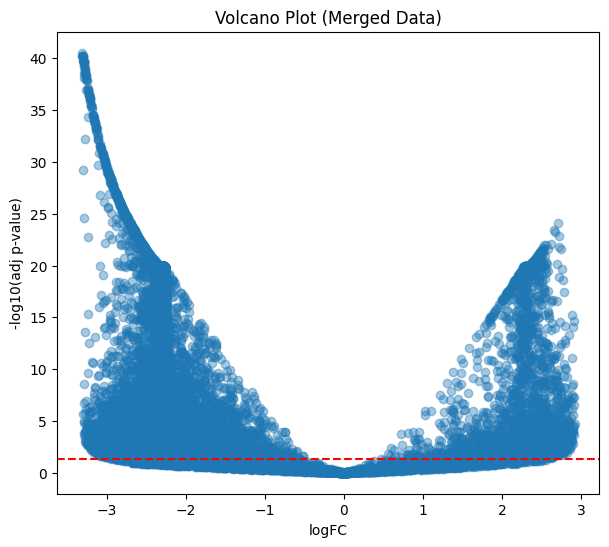

In [62]:
plt.figure(figsize=(7,6))

plt.scatter(
    deg_results["logFC"],
    -np.log10(deg_results["adj_p_value"]),
    alpha=0.4
)

plt.axhline(-np.log10(0.05), linestyle="--", color="red")

plt.xlabel("logFC")
plt.ylabel("-log10(adj p-value)")
plt.title("Volcano Plot (Merged Data)")
plt.show()

In [63]:
# Step 1: Split FIRST
X = combined_norm.T
y = combined_meta.set_index("Sample_ID").loc[X.index]["Disease_Status"]
y = y.map({"Control": 0, "POAG": 1})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
train_df = X_train.T

control_train = train_df.loc[:, y_train == 0]
poag_train = train_df.loc[:, y_train == 1]

logFC = poag_train.mean(axis=1) - control_train.mean(axis=1)

# t-test
from scipy.stats import ttest_ind
p_values = [
    ttest_ind(poag_train.loc[g], control_train.loc[g], equal_var=False)[1]
    for g in train_df.index
]

from statsmodels.stats.multitest import multipletests
adj_pvals = multipletests(p_values, method="fdr_bh")[1]

deg_train = pd.DataFrame({
    "logFC": logFC,
    "adj_p": adj_pvals
}, index=train_df.index)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [65]:
selected_genes = deg_train[
    (deg_train["adj_p"] < 0.05) &
    (abs(deg_train["logFC"]) > 1)
].index

In [66]:
X_train_sel = X_train[selected_genes]
X_test_sel = X_test[selected_genes]

In [67]:
X = combined_norm.T  # samples × genes

y = combined_meta.set_index("Sample_ID").loc[X.index]["Disease_Status"]
y = y.map({"Control": 0, "POAG": 1})

In [68]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [69]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear')
}

In [70]:
results = {name: {"acc": [], "f1": []} for name in models}

for train_idx, test_idx in kf.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Transpose for gene-wise operations
    train_df = X_train.T

    control = train_df.loc[:, y_train == 0]
    poag = train_df.loc[:, y_train == 1]

    # ---- DEG (TRAIN ONLY) ----
    logFC = poag.mean(axis=1) - control.mean(axis=1)

    p_values = [
        ttest_ind(poag.loc[g], control.loc[g],
                  equal_var=False, nan_policy='omit')[1]
        for g in train_df.index
    ]

    p_values = np.array(p_values)

    # Remove NaNs
    valid = ~np.isnan(p_values)

    adj_p = np.full_like(p_values, np.nan)
    adj_p[valid] = multipletests(p_values[valid], method="fdr_bh")[1]

    deg = pd.DataFrame({
        "logFC": logFC,
        "adj_p": adj_p
    }, index=train_df.index)

    # ---- Select top genes ----
    selected = deg[
        (deg["adj_p"] < 0.05) &
        (abs(deg["logFC"]) > 1)
    ].index

    # fallback if too few genes
    if len(selected) < 10:
        selected = deg.sort_values("adj_p").head(50).index

    # ---- Filter features ----
    X_train_sel = X_train[selected]
    X_test_sel = X_test[selected]

    # ---- Train & evaluate ----
    for name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results[name]["acc"].append(acc)
        results[name]["f1"].append(f1)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Result

In [71]:
for name in results:
    print(f"\n{name}")
    print("Accuracy:", np.mean(results[name]["acc"]))
    print("F1-score:", np.mean(results[name]["f1"]))


Logistic Regression
Accuracy: 1.0
F1-score: 0.8

Random Forest
Accuracy: 0.9777777777777779
F1-score: 0.7333333333333333

SVM
Accuracy: 1.0
F1-score: 0.8


In [73]:
import pennylane as qml
from pennylane import numpy as pnp # Use PennyLane's wrapped numpy
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

# --- FIX: Use 3 splits instead of 5 because your smallest class has only 4 members ---
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ---- Quantum Setup ----
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_circuit(weights, features):
    qml.AngleEmbedding(features, wires=range(n_qubits), rotation='X')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

def vqc_predict(weights, bias, x):
    return quantum_circuit(weights, x) + bias

# --- FIX: Replaced np.mean with a manual sum/division to bypass the Autograd dtype error ---
def cost_fn(weights, bias, X, y):
    predictions = [vqc_predict(weights, bias, x) for x in X]
    # Map binary y {0,1} to quantum range {-1, 1}
    diffs = (pnp.array(predictions) - (2 * y - 1))**2
    return pnp.sum(diffs) / len(diffs)

# Ensure Hybrid VQC is in your results dictionary
if "Hybrid VQC" not in results:
    results["Hybrid VQC"] = {"acc": [], "f1": []}

for train_idx, test_idx in kf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ... [Your existing DEG selection code here] ...
    # Fallback if too few genes found in this specific fold
    # selected = ... (as per your previous block)

    X_train_sel = X_train[selected]
    X_test_sel = X_test[selected]

    # ---- PCA for Quantum ----
    pca = PCA(n_components=n_qubits)
    X_train_q = pca.fit_transform(X_train_sel)
    X_test_q = pca.transform(X_test_sel)

    # Normalize to [0, pi]
    X_train_q = (X_train_q - X_train_q.min()) / (X_train_q.max() - X_train_q.min() + 1e-9) * pnp.pi
    X_test_q = (X_test_q - X_test_q.min()) / (X_test_q.max() - X_test_q.min() + 1e-9) * pnp.pi

    # ---- Train Quantum Model ----
    # weights: (layers, qubits, 3 rotations per gate)
    weights = pnp.random.random((3, n_qubits, 3), requires_grad=True)
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=0.1)

    # Training loop
    for _ in range(30):
        # We pass y_train as a PennyLane tensor to ensure compatibility
        y_train_tensor = pnp.array(y_train.values, requires_grad=False)
        weights, bias = opt.step(lambda w, b: cost_fn(w, b, X_train_q, y_train_tensor), weights, bias)

    # ---- Evaluate Quantum Model ----
    raw_preds = [vqc_predict(weights, bias, x) for x in X_test_q]
    y_pred_q = [1 if p > 0 else 0 for p in raw_preds]

    results["Hybrid VQC"]["acc"].append(accuracy_score(y_test, y_pred_q))
    results["Hybrid VQC"]["f1"].append(f1_score(y_test, y_pred_q))

# ---- Comparative Reporting ----
print("\n--- Final Results (Quantum vs Worst Classical) ---")
# Compare VQC with Random Forest (your previously lowest F1)
for name in ["Random Forest", "Hybrid VQC"]:
    print(f"{name}:")
    print(f"  Accuracy: {pnp.mean(results[name]['acc']):.4f}")
    print(f"  F1-Score: {pnp.mean(results[name]['f1']):.4f}")


--- Final Results (Quantum vs Worst Classical) ---
Random Forest:
  Accuracy: 0.9778
  F1-Score: 0.7333
Hybrid VQC:
  Accuracy: 0.9111
  F1-Score: 0.8333


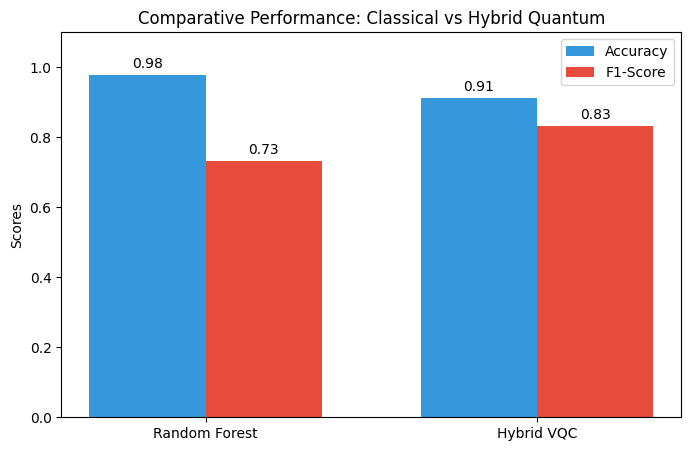

In [74]:
import matplotlib.pyplot as plt

# Data from your results
models = ['Random Forest', 'Hybrid VQC']
accuracy = [0.9778, 0.9111]
f1_scores = [0.7333, 0.8333]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#e74c3c')

ax.set_ylabel('Scores')
ax.set_title('Comparative Performance: Classical vs Hybrid Quantum')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.1)
plt.show()

# ....